In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import warnings

import keras
from keras import Sequential
from keras.layers import Dense

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 한글 경고 제거
warnings.filterwarnings(action="ignore", category=UserWarning)

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# Iris 데이터셋 로드
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("target names:", iris.target_names)

X shape: (150, 4)
y shape: (150,)
target names: ['setosa' 'versicolor' 'virginica']


In [ ]:
# 학습용 데이터와 검증용 데이터를 분리
# Train은 모델이 배우는 데이터, Validation은 학습 중 성능을 확인하는 데이터
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 특성 값의 스케일을 평균 0, 표준편차 1로 맞춤
# 꽃받침 길이와 꽃잎 길이의 단위 차이가 모델 학습에 영향을 주지 않도록 조정
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)  # train에는 fit_transform
X_val_s = scaler.transform(X_val)          # validation에는 transform만 적용

In [ ]:
# 단층 모델과 2층 MLP 모델의 결과를 한곳에 저장할 리스트 생성
# 모델명, 구조, 파라미터 수, 검증 정확도를 표로 비교하기 위함
results = []

In [ ]:
# 재현성을 위한 시드 고정
keras.utils.set_random_seed(42)

# 단층 Softmax 모델 생성
# 입력층에서 바로 출력층으로 연결되는 단층 Softmax 모델 생성
# 입력 특성 4개를 받아 Iris 품종 3개 중 하나의 확률로 출력
model_single = Sequential([Dense(3, activation="softmax", input_shape=(4,))])

# 모델 구조 확인
# 단층 모델의 구조와 파라미터 수 확인
# 입력 4개 × 출력 3개 + bias 3개 = 총 15개 파라미터
model_single.summary()

# 모델 컴파일
# 모델 학습 방식을 설정
# sparse_categorical_crossentropy는 정답이 0, 1, 2처럼 정수 라벨일 때 사용
model_single.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# 모델 학습
# 단층 모델을 200번 반복 학습
# epochs=200은 전체 학습 데이터를 200번 반복해서 보겠다는 의미
history_single = model_single.fit(
    X_train_s, y_train, epochs=200, validation_data=(X_val_s, y_val), verbose=0
)

# 검증 데이터로 단층 모델 성능 평가
# 학습에 직접 사용하지 않은 데이터에서 정확도를 확인
val_loss_single, val_acc_single = model_single.evaluate(X_val_s, y_val, verbose=0)

# 결과 저장
# 단층 모델의 파라미터 수와 검증 정확도를 results 리스트에 저장
# 이후 2층 MLP 결과와 비교하기 위함
results.append(
    {
        "model": "단층",
        "structure": "Dense(3, softmax)",
        "params": model_single.count_params(),
        "val_accuracy": val_acc_single,
    }
)

print("단층 검증 정확도:", val_acc_single)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

단층 검증 정확도: 0.7666666507720947


In [ ]:
# 재현성을 위한 시드 고정
keras.utils.set_random_seed(42)

# 2층 MLP 모델 생성
# 은닉층 8개를 추가한 2층 MLP 모델 생성
# 입력 4개 → 은닉층 8개 → 출력 3개 구조
model_two = Sequential(
    [Dense(8, activation="sigmoid", input_shape=(4,)), Dense(3, activation="softmax")]
)

# 모델 구조 확인
# 2층 MLP 모델의 구조와 파라미터 수 확인
# 첫 층 40개 + 출력층 27개 = 총 67개 파라미터
model_two.summary()


# 모델 컴파일
# 2층 MLP 모델의 학습 방식을 설정
# 단층 모델과 동일한 손실 함수와 평가 지표를 사용하여 공정하게 비교
model_two.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# 모델 학습
# 2층 MLP 모델을 200번 반복 학습
# 은닉층을 통해 Iris 데이터의 비선형 패턴을 학습할 수 있는지 확인
history_two = model_two.fit(
    X_train_s, y_train, epochs=200, validation_data=(X_val_s, y_val), verbose=0
)


# 검증 데이터로 2층 MLP 모델 성능 평가
# 단층 모델보다 정확도가 향상되는지 확인
val_loss_two, val_acc_two = model_two.evaluate(X_val_s, y_val, verbose=0)


# 결과 저장
# 2층 MLP 모델의 파라미터 수와 검증 정확도를 저장
# 파라미터가 증가했을 때 성능도 함께 증가했는지 비교
results.append(
    {
        "model": "2층 MLP",
        "structure": "Dense(8, sigmoid) → Dense(3, softmax)",
        "params": model_two.count_params(),
        "val_accuracy": val_acc_two,
    }
)

print("2층 MLP 검증 정확도:", val_acc_two)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

2층 MLP 검증 정확도: 0.8333333134651184


```text
input_shape = 입력 특성 개수(feature 수)

Dense(8) = 은닉층 뉴런 개수

Dense(3) = 출력 클래스 개수

Output Shape = 해당 층의 출력 뉴런 개수

In [8]:
result_df = pd.DataFrame(results)
result_df

,model,structure,params,val_accuracy
0,단층,"Dense(3, softmax)",15,0.766667
1,2층 MLP,"Dense(8, sigmoid) → Dense(3, softmax)",67,0.833333


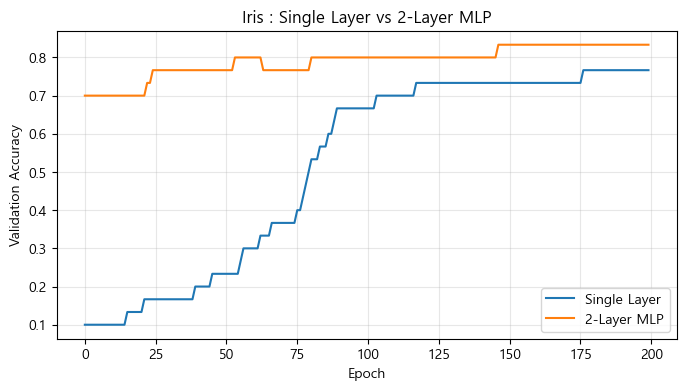

In [ ]:
# 단층 모델과 2층 MLP의 Validation Accuracy 변화를 곡선 그래프로 비교
# 어떤 모델이 더 빠르게 수렴하고 최종 정확도가 높은지 확인

plt.figure(figsize=(8, 4))

plt.plot(history_single.history["val_accuracy"], label="Single Layer")

plt.plot(history_two.history["val_accuracy"], label="2-Layer MLP")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Iris : Single Layer vs 2-Layer MLP")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### 실험 결과 해석
2층 MLP는 은닉층을 추가하여 더 복잡한 비선형 관계를 학습할 수 있다.

그래프를 보면 단층 모델보다 빠르게 수렴하거나 더 높은 Validation Accuracy를 보일 수 있다.

다만 Iris 데이터셋은 비교적 단순한 데이터이므로 성능 차이가 크지 않을 수도 있다.

따라서 파라미터 수가 증가한다고 항상 성능이 크게 향상되는 것은 아니며, 데이터의 복잡도에 적합한 모델 구조를 선택하는 것이 중요하다.